--- ANÁLISIS POR TIENDA ---

Resultados Tienda 1:
- Ingreso Total: $1,150,880,400.00
- Calificación Promedio: 3.98
- Costo de Envío Promedio: $26,018.61
- Categoría más vendida: Muebles
- Producto más vendido: Microondas
- Producto menos vendido: Auriculares con micrófono

Resultados Tienda 2:
- Ingreso Total: $1,116,343,500.00
- Calificación Promedio: 4.04
- Costo de Envío Promedio: $25,216.24
- Categoría más vendida: Muebles
- Producto más vendido: Iniciando en programación
- Producto menos vendido: Juego de mesa

Resultados Tienda 3:
- Ingreso Total: $1,098,019,600.00
- Calificación Promedio: 4.05
- Costo de Envío Promedio: $24,805.68
- Categoría más vendida: Muebles
- Producto más vendido: Kit de bancas
- Producto menos vendido: Bloques de construcción

Resultados Tienda 4:
- Ingreso Total: $1,038,375,700.00
- Calificación Promedio: 4.00
- Costo de Envío Promedio: $23,459.46
- Categoría más vendida: Muebles
- Producto más vendido: Cama box
- Producto menos vendido: Guitarra eléctri

/tmp/ipykernel_1100/27756676.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Tienda', y='Ingresos', data=df_resumen, palette='viridis')


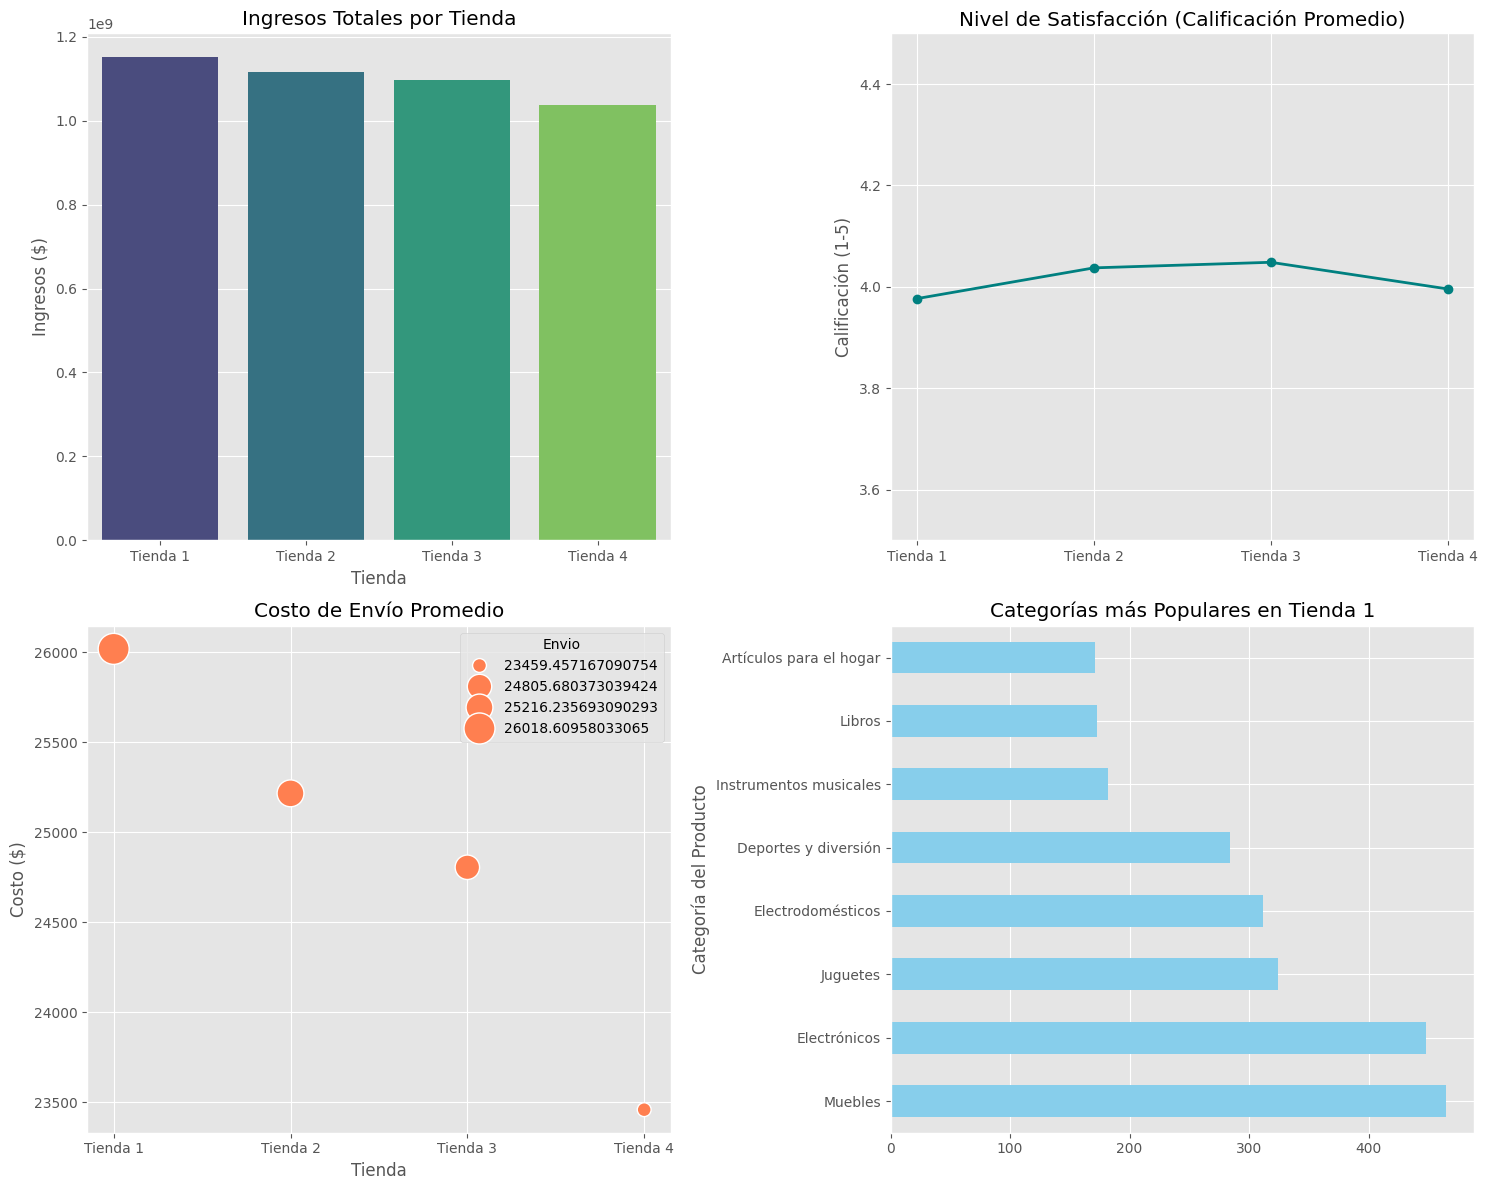

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = ['tienda_1 .csv', 'tienda_2.csv', 'tienda_3.csv', 'tienda_4.csv']
tiendas_nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
dfs = [pd.read_csv(f) for f in files]

# Preparación de listas para almacenar resultados
resumen_tiendas = []

print("--- ANÁLISIS POR TIENDA ---")

for i, df in enumerate(dfs):
    nombre = tiendas_nombres[i]

    # 1. Ingreso Total
    ingreso_total = df['Precio'].sum()

      # 2. Cantidad por Categoría
    cat_counts = df['Categoría del Producto'].value_counts()
    top_categoria = cat_counts.idxmax()

    # 3. Calificación Promedio
    calif_promedio = df['Calificación'].mean()

    # 4. Productos más y menos vendidos
    prod_counts = df['Producto'].value_counts()
    top_producto = prod_counts.idxmax()
    peor_producto = prod_counts.idxmin()

    # 5. Costo de envío promedio
    envio_promedio = df['Costo de envío'].mean()

    # Guardar resultados
    resumen_tiendas.append({
        'Tienda': nombre,
        'Ingresos': ingreso_total,
        'Calificacion': calif_promedio,
        'Envio': envio_promedio,
        'Top_Cat': top_categoria,
        'Top_Prod': top_producto
    })

    print(f"\nResultados {nombre}:")
    print(f"- Ingreso Total: ${ingreso_total:,.2f}")
    print(f"- Calificación Promedio: {calif_promedio:.2f}")
    print(f"- Costo de Envío Promedio: ${envio_promedio:,.2f}")
    print(f"- Categoría más vendida: {top_categoria}")
    print(f"- Producto más vendido: {top_producto}")
    print(f"- Producto menos vendido: {peor_producto}")

# Convertir a DataFrame para graficar
df_resumen = pd.DataFrame(resumen_tiendas)

# --- VISUALIZACIONES ---

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Ingresos Totales (Barras)
sns.barplot(ax=axes[0, 0], x='Tienda', y='Ingresos', data=df_resumen, palette='viridis')
axes[0, 0].set_title('Ingresos Totales por Tienda')
axes[0, 0].set_ylabel('Ingresos ($)')

# Gráfico 2: Calificación Promedio (Líneas con Marcadores)
axes[0, 1].plot(df_resumen['Tienda'], df_resumen['Calificacion'], marker='o', linestyle='-', color='teal', linewidth=2)
axes[0, 1].set_title('Nivel de Satisfacción (Calificación Promedio)')
axes[0, 1].set_ylim(3.5, 4.5)
axes[0, 1].set_ylabel('Calificación (1-5)')

# Gráfico 3: Costo de Envío Promedio (Dispersión)
sns.scatterplot(ax=axes[1, 0], x='Tienda', y='Envio', size='Envio', sizes=(100, 500), data=df_resumen, color='coral')
axes[1, 0].set_title('Costo de Envío Promedio')
axes[1, 0].set_ylabel('Costo ($)')

# Gráfico 4: Distribución de Categorías de la Tienda Líder (Barras Horizontales)
tienda_lider = df_resumen.loc[df_resumen['Ingresos'].idxmax(), 'Tienda']
idx_lider = tiendas_nombres.index(tienda_lider)
dfs[idx_lider]['Categoría del Producto'].value_counts().plot(kind='barh', ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title(f'Categorías más Populares en {tienda_lider}')

plt.tight_layout()
plt.show()

